In [1]:
#!pip install -U transformers accelerate datasets bitsandbytes scipy scikit-learn matplotlib

In [ ]:
import os
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = '/content/drive/MyDrive/LPP/data'   # <-- folder holding final_data.csv, etc.
except Exception:
    PROJECT_DIR = os.path.join('..', 'data')   # local run from notebooks/
os.makedirs(PROJECT_DIR, exist_ok=True); os.chdir(PROJECT_DIR)
print('Working dir:', os.getcwd())
# !nvidia-smi -L

In [ ]:
# Hugging Face auth (needed for Llama/Mistral gated repos)
import os
os.environ.setdefault('HF_TOKEN', '')   # set HF_TOKEN in your environment; never commit tokens
!hf auth login --token $HF_TOKEN

In [4]:
import os, numpy as np, pandas as pd

# short-name -> HF id  (same 8 models as the paper)
MODEL_MAP = {
    "Qwen-0.5B": "Qwen/Qwen2.5-0.5B-Instruct",
    "Qwen-1.5B": "Qwen/Qwen2.5-1.5B-Instruct",
    "Qwen-3B":   "Qwen/Qwen2.5-3B-Instruct",
    "Qwen-7B":   "Qwen/Qwen2.5-7B-Instruct",
    "Qwen-14B":  "Qwen/Qwen2.5-14B-Instruct",
    "Llama-3B":  "meta-llama/Llama-3.2-3B-Instruct",
    "Llama-8B":  "meta-llama/Meta-Llama-3-8B-Instruct",
    "Mistral-7B":"mistralai/Mistral-7B-Instruct-v0.2",
}

# calibration data settings (match the paper)
N_SAMPLES   = 100          # Alpaca prompts
PREFIX_LEN  = 100          # designated prefix length
MAX_LENGTH  = 200          # max context length
BATCH_SIZE  = 8
TOKEN_CAP   = 2048
ROBUST_TOPK = 5            # dims to winsorize in the 'robust' variant
SEED        = 42
np.random.seed(SEED)

LPP_TABLE = "final_data.csv"   # canonical per-model LPP + task + benchmark table
OUT_METRICS = "normalized_metrics.csv"
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

In [5]:
def participation_ratio(eigvals):
    s = np.clip(eigvals, 0, None)
    out = float((s.sum() ** 2) / (np.square(s).sum() + 1e-12)) if s.sum() > 0 else 0.0
    return out / eigvals.shape[-1]

def effective_rank(eigvals):
    s = np.clip(eigvals, 1e-12, None)
    p = s / s.sum()
    h = -(p * np.log(p)).sum()
    return float(np.exp(h)) / eigvals.shape[-1]

def preprocess_matrix(H, mode="raw", topk=ROBUST_TOPK):
    """H: (tokens, D) hidden states for one layer. Returns centered/scaled matrix."""
    Hc = H - H.mean(axis=0, keepdims=True)          # mean-center (current behaviour)
    if mode == "raw":
        return Hc
    if mode == "zscore":                            # standardize -> correlation matrix spectrum
        sd = Hc.std(axis=0, keepdims=True)
        sd[sd < 1e-8] = 1.0
        return Hc / sd
    if mode == "robust":                            # winsorize the top-k highest-variance dims
        var = Hc.var(axis=0)
        hi = np.argsort(var)[-topk:]
        Hr = Hc.copy()
        for d in hi:                                # clip to +/- 3 std of that dimension
            s = Hr[:, d].std() + 1e-8
            Hr[:, d] = np.clip(Hr[:, d], -3*s, 3*s)
        return Hr
    raise ValueError(mode)

def spectrum(H):
    """eigenvalues of the (D x D) covariance estimated across the token axis."""
    from scipy.linalg import svd
    U, S, Vt = svd(H, full_matrices=False)
    return (S ** 2) / max(H.shape[0] - 1, 1)

def top_variance_share(H, k=5):
    """Fraction of total activation variance carried by the top-1 and top-k raw dimensions."""
    Hc = H - H.mean(axis=0, keepdims=True)
    var = Hc.var(axis=0)
    order = np.sort(var)[::-1]
    tot = order.sum() + 1e-12
    return float(order[0] / tot), float(order[:k].sum() / tot)

In [6]:
import torch, torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset

# ---- calibration texts: 100 Alpaca prompts (same source as the paper) ----
alp = load_dataset("tatsu-lab/alpaca", split="train")
texts = []
for ex in alp.select(range(N_SAMPLES)):
    t = ex["instruction"] + (("\n" + ex["input"]) if ex.get("input") else "")
    texts.append(t)
print(f"{len(texts)} calibration prompts")

@torch.no_grad()
def collect_lastlayer_hidden(model, tok, texts):
    """Return stacked last-layer token hidden states (tokens, D) and mean next-token entropy."""
    chunks, ents = [], []
    for start in range(0, len(texts), BATCH_SIZE):
        enc = tok(texts[start:start+BATCH_SIZE], return_tensors="pt",
                  padding=True, truncation=True, max_length=MAX_LENGTH)
        ids  = enc["input_ids"][:, :PREFIX_LEN].to(model.device)
        attn = enc["attention_mask"][:, :PREFIX_LEN].to(model.device)
        out = model(input_ids=ids, attention_mask=attn, output_hidden_states=True, use_cache=False)
        last_idx = attn.sum(1) - 1
        for i in range(ids.shape[0]):
            p = F.softmax(out.logits[i, last_idx[i]], dim=-1)
            ents.append(float(-(p * p.clamp_min(1e-12).log()).sum()))
        last_h = out.hidden_states[-1]                      # (B, T, D) last layer
        mask = attn.unsqueeze(-1)
        h = (last_h * mask).detach().cpu().float().numpy()
        h = h.reshape(-1, last_h.shape[-1])                 # (B*T, D)
        m = attn.reshape(-1).bool().cpu().numpy()
        h = h[m]                                            # keep real tokens only
        chunks.append(h)
    H = np.concatenate(chunks, 0)
    if H.shape[0] > TOKEN_CAP:
        H = H[np.random.choice(H.shape[0], TOKEN_CAP, replace=False)]
    return H, float(np.mean(ents))

rows = []
for short, hf_id in MODEL_MAP.items():
    print("==>", short, hf_id)
    tok = AutoTokenizer.from_pretrained(hf_id, use_fast=True)
    if tok.pad_token is None: tok.pad_token = tok.eos_token
    tok.padding_side = "left"
    model = AutoModelForCausalLM.from_pretrained(hf_id, torch_dtype=torch.float16,
                                                 device_map="auto")
    model.eval()
    H, ent = collect_lastlayer_hidden(model, tok, texts)
    v1, v5 = top_variance_share(H, k=5)
    row = {"Model": short, "Entropy_recomputed": ent,
           "top1_var_share": v1, "top5_var_share": v5}
    for mode in ("raw", "zscore", "robust"):
        eig = spectrum(preprocess_matrix(H, mode))
        row[f"PR_{mode}"] = participation_ratio(eig)
        row[f"ER_{mode}"] = effective_rank(eig)
    rows.append(row)
    del model; torch.cuda.empty_cache()

norm_df = pd.DataFrame(rows)
norm_df.to_csv(OUT_METRICS, index=False)
norm_df.round(4)

README.md:   0%|          | 0.00/7.47k [00:00<?, ?B/s]

data/train-00000-of-00001-a09b74b3ef9c3b(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/52002 [00:00<?, ? examples/s]

100 calibration prompts
==> Qwen-0.5B Qwen/Qwen2.5-0.5B-Instruct


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/25.1k [00:00<?, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

,Model,Entropy_recomputed,top1_var_share,top5_var_share,PR_raw,ER_raw,PR_zscore,ER_zscore,PR_robust,ER_robust
0,Qwen-0.5B,NaN,0.0581,0.2157,0.0236,0.0909,0.0948,0.2686,0.0236,0.0910
1,Qwen-1.5B,NaN,0.1687,0.3046,0.0098,0.0516,0.0808,0.2235,0.0100,0.0525
2,Qwen-3B,NaN,0.1622,0.2894,0.0092,0.0519,0.0889,0.2477,0.0093,0.0527
3,Qwen-7B,NaN,0.0776,0.2531,0.0113,0.0514,0.0834,0.2645,0.0113,0.0515
4,Qwen-14B,NaN,0.1259,0.2576,0.0091,0.0421,0.0426,0.1845,0.0091,0.0422
5,Llama-3B,NaN,0.0270,0.0540,0.0254,0.1320,0.0540,0.1982,0.0256,0.1327
6,Llama-8B,NaN,0.0105,0.0393,0.0199,0.1063,0.0380,0.1632,0.0199,0.1063
7,Mistral-7B,NaN,0.0538,0.1386,0.0213,0.1259,0.0970,0.2921,0.0218,0.1281


In [7]:
from scipy.stats import spearmanr
norm_df = pd.read_csv(OUT_METRICS)

print("Outlier concentration (fraction of variance in top dims):")
print(norm_df[["Model","top1_var_share","top5_var_share"]].round(3).to_string(index=False))
print(f"\nMean top-1 share: {norm_df.top1_var_share.mean():.3f} | "
      f"mean top-5 share: {norm_df.top5_var_share.mean():.3f}")

print("\nSpearman rank correlation of model ordering: raw vs normalized variants")
for metric in ("PR","ER"):
    for mode in ("zscore","robust"):
        rho, p = spearmanr(norm_df[f"{metric}_raw"], norm_df[f"{metric}_{mode}"])
        print(f"  {metric}: raw vs {mode:7s}  rho={rho:+.3f}  p={p:.3g}")

Outlier concentration (fraction of variance in top dims):
     Model  top1_var_share  top5_var_share
 Qwen-0.5B           0.058           0.216
 Qwen-1.5B           0.169           0.305
   Qwen-3B           0.162           0.289
   Qwen-7B           0.078           0.253
  Qwen-14B           0.126           0.258
  Llama-3B           0.027           0.054
  Llama-8B           0.011           0.039
Mistral-7B           0.054           0.139

Mean top-1 share: 0.086 | mean top-5 share: 0.194

Spearman rank correlation of model ordering: raw vs normalized variants
  PR: raw vs zscore   rho=+0.238  p=0.57
  PR: raw vs robust   rho=+1.000  p=0
  ER: raw vs zscore   rho=+0.119  p=0.779
  ER: raw vs robust   rho=+1.000  p=0


In [8]:
lpp = pd.read_csv(LPP_TABLE)          # Model, IFEval, BBH, MMLU-PRO, Entropy, PR, ER, SPC, AR
merged = lpp.merge(norm_df, on="Model", how="inner")

targets = ["SPC", "AR", "IFEval", "BBH", "MMLU-PRO"]
out = []
for mode in ("raw","zscore","robust"):
    for metric in ("PR","ER"):
        col = f"{metric}_{mode}"
        for t in targets:
            rho, p = spearmanr(merged[col], merged[t])
            out.append({"preprocess":mode,"metric":metric,"target":t,
                        "spearman_rho":round(rho,3),"p":round(p,3)})
res = pd.DataFrame(out)
piv = res.pivot_table(index=["metric","target"], columns="preprocess", values="spearman_rho")
print("Spearman rho (metric vs target) under each preprocessing:\n")
print(piv.round(3).to_string())
res.to_csv("normalized_correlations.csv", index=False)

Spearman rho (metric vs target) under each preprocessing:

preprocess         raw  robust  zscore
metric target                         
ER     AR       -0.204  -0.204  -0.024
       BBH      -0.476  -0.476  -0.524
       IFEval   -0.381  -0.381  -0.571
       MMLU-PRO -0.571  -0.571  -0.619
       SPC      -0.762  -0.762   0.143
PR     AR       -0.419  -0.419  -0.048
       BBH      -0.548  -0.548  -0.571
       IFEval   -0.405  -0.405  -0.643
       MMLU-PRO -0.619  -0.619  -0.667
       SPC      -0.690  -0.690   0.095


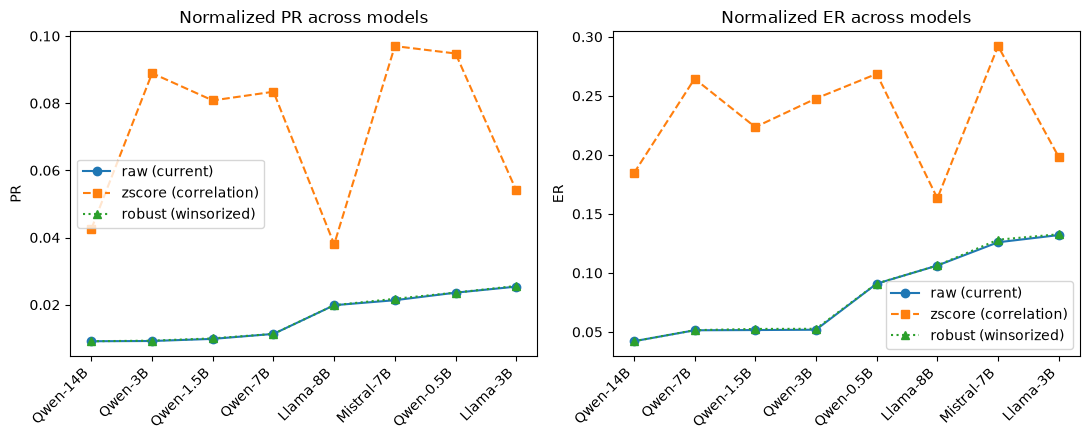

In [9]:
# Visual: rankings under raw vs zscore for PR and ER
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
for ax, metric in zip(axes, ("PR","ER")):
    d = norm_df.sort_values(f"{metric}_raw")
    x = np.arange(len(d))
    ax.plot(x, d[f"{metric}_raw"].values,   "o-", label="raw (current)")
    ax.plot(x, d[f"{metric}_zscore"].values,"s--",label="zscore (correlation)")
    ax.plot(x, d[f"{metric}_robust"].values,"^:", label="robust (winsorized)")
    ax.set_xticks(x); ax.set_xticklabels(d["Model"], rotation=45, ha="right")
    ax.set_title(f"Normalized {metric} across models"); ax.set_ylabel(metric); ax.legend()
plt.tight_layout(); plt.savefig("normalized_scores_comparison.png", dpi=200); plt.show()